# Importing data From Methane Database

In [1]:
import pyodbc
import pandas as pd
import numpy as np

In [2]:
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=.\SQLEXPRESS;'
    'DATABASE=Methane;'
    'Trusted_Connection=yes;'
)

query = "select * from [Final Dataaa2]"
df = pd.read_sql(query, conn)

<>:3: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:3: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\lenovo\AppData\Local\Temp\ipykernel_16576\3705677188.py:3: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  'SERVER=.\SQLEXPRESS;'
C:\Users\lenovo\AppData\Local\Temp\ipykernel_16576\3705677188.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


# Preprocessing & Cleaning

In [3]:
df.head(5)

,facility_id,facility_name,source_type,iso3,subsector,start_time,end_time,year,month,lat,...,recommended_strategy_name,recommended_strategy_description,recommended_difficulty_score,recommended_total_emissions_reduced_per_year,gdp,population,co2,methane,energy_per_capita,known_super_emitter_flag
0,CT-100000,United Transport Site 1,point-source,ARE,oil-and-gas-transport,2024-05-11,2024-06-07,2024,5,-35.500702,...,Reduce Flaring,Replace routine flaring with gas capture/reinj...,3,85.059998,5.000000e+11,10000000,16207324.0,1361147.375,21792.134766,False
1,CT-100000,United Transport Site 1,point-source,ARE,oil-and-gas-transport,2024-05-11,2024-06-07,2024,5,-35.500702,...,Reduce Flaring,Replace routine flaring with gas capture/reinj...,3,85.059998,5.000000e+11,10000000,16207324.0,1361147.375,86209.445312,False
2,CT-100000,United Transport Site 1,point-source,ARE,oil-and-gas-transport,2024-10-08,2024-11-04,2024,10,-35.500702,...,Reduce Flaring,Replace routine flaring with gas capture/reinj...,3,85.059998,5.000000e+11,10000000,16207324.0,1361147.375,72490.015625,False
3,CT-100000,United Transport Site 1,point-source,ARE,oil-and-gas-transport,2024-11-07,2024-12-04,2024,11,-35.500702,...,Reduce Flaring,Replace routine flaring with gas capture/reinj...,3,85.059998,5.000000e+11,10000000,16207324.0,1361147.375,32991.300781,False
4,CT-100000,United Transport Site 1,point-source,ARE,oil-and-gas-transport,2024-12-07,2025-01-03,2024,12,-35.500702,...,Reduce Flaring,Replace routine flaring with gas capture/reinj...,3,85.059998,5.000000e+11,10000000,16207324.0,1361147.375,48803.656250,False


In [4]:
df['recommended_total_emissions_reduced_per_year'] = np.minimum(
    df['recommended_total_emissions_reduced_per_year'], df['emission_quantity']
)

In [5]:
jan_2026_clean = (
    df[(df['year'] == 2026) & (df['month'] == 1)]
    .groupby(['facility_id', 'year', 'month'], as_index=False)
    .agg({'emission_quantity': 'mean'}) 
)

In [6]:
df.groupby('iso3')['year'].unique()

iso3
AGO    [2024, 2025, 2026]
ARE    [2024, 2025, 2026]
BRA    [2024, 2025, 2026]
CAN    [2024, 2025, 2026]
CHN    [2025, 2024, 2026]
DZA    [2024, 2025, 2026]
EGY    [2024, 2025, 2026]
GBR    [2025, 2024, 2026]
IDN    [2024, 2025, 2026]
IRQ    [2025, 2026, 2024]
KAZ    [2024, 2025, 2026]
KWT    [2024, 2025, 2026]
MEX    [2024, 2025, 2026]
NGA    [2024, 2025, 2026]
NOR    [2024, 2025, 2026]
QAT    [2024, 2025, 2026]
RUS    [2024, 2025, 2026]
SAU    [2024, 2025, 2026]
TKM    [2024, 2025, 2026]
USA    [2024, 2025, 2026]
Name: year, dtype: object

In [7]:
print(len(df.columns))

24


In [8]:
kwh_map = {
    'QAT': 175000.0,
    'ARE': 135000.0,
    'KWT': 105000.0,
    'CAN': 102000.0,
    'NOR': 98000.0,
    'SAU': 85000.0,
    'USA': 78000.0,
    'TKM': 62000.0,
    'RUS': 56000.0,
    'KAZ': 48000.0,
    'CHN': 32000.0,
    'GBR': 29000.0,
    'DZA': 16000.0,
    'BRA': 15500.0,
    'MEX': 15000.0,
    'IRQ': 14500.0,
    'EGY': 10500.0,
    'IDN': 9200.0,
    'AGO': 3100.0,
    'NGA': 1800.0,
}


df['energy_per_capita'] = (
    df['iso3'].map(kwh_map) * (1 + 0.008 * (df['year'] - 2024))
).round(4)


print(df.shape)

(21679, 24)


In [9]:
df.head(15)

,facility_id,facility_name,source_type,iso3,subsector,start_time,end_time,year,month,lat,...,recommended_strategy_name,recommended_strategy_description,recommended_difficulty_score,recommended_total_emissions_reduced_per_year,gdp,population,co2,methane,energy_per_capita,known_super_emitter_flag
0,CT-100000,United Transport Site 1,point-source,ARE,oil-and-gas-transport,2024-05-11,2024-06-07,2024,5,-35.500702,...,Reduce Flaring,Replace routine flaring with gas capture/reinj...,3,85.059998,5.000000e+11,10000000,16207324.0,1361147.375,135000.0,False
1,CT-100000,United Transport Site 1,point-source,ARE,oil-and-gas-transport,2024-05-11,2024-06-07,2024,5,-35.500702,...,Reduce Flaring,Replace routine flaring with gas capture/reinj...,3,85.059998,5.000000e+11,10000000,16207324.0,1361147.375,135000.0,False
2,CT-100000,United Transport Site 1,point-source,ARE,oil-and-gas-transport,2024-10-08,2024-11-04,2024,10,-35.500702,...,Reduce Flaring,Replace routine flaring with gas capture/reinj...,3,85.059998,5.000000e+11,10000000,16207324.0,1361147.375,135000.0,False
3,CT-100000,United Transport Site 1,point-source,ARE,oil-and-gas-transport,2024-11-07,2024-12-04,2024,11,-35.500702,...,Reduce Flaring,Replace routine flaring with gas capture/reinj...,3,85.059998,5.000000e+11,10000000,16207324.0,1361147.375,135000.0,False
4,CT-100000,United Transport Site 1,point-source,ARE,oil-and-gas-transport,2024-12-07,2025-01-03,2024,12,-35.500702,...,Reduce Flaring,Replace routine flaring with gas capture/reinj...,3,85.059998,5.000000e+11,10000000,16207324.0,1361147.375,135000.0,False
5,CT-100000,United Transport Site 1,point-source,ARE,oil-and-gas-transport,2025-04-06,2025-05-03,2025,4,-35.500702,...,Reduce Flaring,Replace routine flaring with gas capture/reinj...,3,85.059998,5.000000e+11,10000000,16207324.0,1361147.375,136080.0,False
6,CT-100000,United Transport Site 1,point-source,ARE,oil-and-gas-transport,2025-07-05,2025-08-01,2025,7,-35.500702,...,Reduce Flaring,Replace routine flaring with gas capture/reinj...,3,85.059998,5.000000e+11,10000000,16207324.0,1361147.375,136080.0,False
7,CT-100000,United Transport Site 1,point-source,ARE,oil-and-gas-transport,2025-07-05,2025-08-01,2025,7,-35.500702,...,Reduce Flaring,Replace routine flaring with gas capture/reinj...,3,85.059998,5.000000e+11,10000000,16207324.0,1361147.375,136080.0,False
8,CT-100000,United Transport Site 1,point-source,ARE,oil-and-gas-transport,2025-09-03,2025-09-30,2025,9,-35.500702,...,Reduce Flaring,Replace routine flaring with gas capture/reinj...,3,85.059998,5.000000e+11,10000000,16207324.0,1361147.375,136080.0,False
9,CT-100000,United Transport Site 1,point-source,ARE,oil-and-gas-transport,2025-09-03,2025-09-30,2025,9,-35.500702,...,Reduce Flaring,Replace routine flaring with gas capture/reinj...,3,85.059998,5.000000e+11,10000000,16207324.0,1361147.375,136080.0,False


In [10]:
df.isnull().sum()

facility_id                                        0
facility_name                                      0
source_type                                        0
iso3                                               0
subsector                                          0
start_time                                         0
end_time                                           0
year                                               0
month                                              0
lat                                                9
lon                                                0
emission_quantity                                891
emissions_quantity_confidence                      0
immediate_source_owner                             0
recommended_strategy_name                          0
recommended_strategy_description                   0
recommended_difficulty_score                       0
recommended_total_emissions_reduced_per_year    1099
gdp                                           

In [11]:
df['lat'] = df.groupby('facility_id')['lat'].transform(
    lambda x: x.ffill().bfill()
)

df['lat'] = df['lat'].fillna(
    df.groupby('iso3')['lat'].transform('first')
)

In [12]:
df['emission_quantity'] = df.groupby('facility_id')[
    'emission_quantity'
].transform(lambda x: x.fillna(x.mean()))

In [13]:

df['reduction_ratio'] = df['recommended_total_emissions_reduced_per_year'] / df['emission_quantity']

strategy_ratios = df.groupby(['recommended_strategy_name', 'subsector'])['reduction_ratio'].transform('mean')

predicted_reductions = df['emission_quantity'] * strategy_ratios

df['recommended_total_emissions_reduced_per_year'] = df['recommended_total_emissions_reduced_per_year'].fillna(predicted_reductions)

df.drop(columns=['reduction_ratio'], inplace=True)

In [15]:

df['gdp'] = df.groupby('iso3')['gdp'].ffill().bfill()

In [45]:
df.duplicated().sum()

np.int64(1)

In [46]:
data.drop_duplicates(inplace=True)

In [16]:
df.isnull().sum()

facility_id                                     0
facility_name                                   0
source_type                                     0
iso3                                            0
subsector                                       0
start_time                                      0
end_time                                        0
year                                            0
month                                           0
lat                                             0
lon                                             0
emission_quantity                               0
emissions_quantity_confidence                   0
immediate_source_owner                          0
recommended_strategy_name                       0
recommended_strategy_description                0
recommended_difficulty_score                    0
recommended_total_emissions_reduced_per_year    0
gdp                                             0
population                                      0


# EDA on the cleaned data

In [ ]:
df.to_excel('TraceIQ_Cleaned_Dataset.xlsx', index=False)

In [ ]:
data = pd.read_excel('TraceIQ_Cleaned_Dataset.xlsx')

In [ ]:
data.duplicated().sum()

np.int64(1)

In [ ]:
data.shape

(21679, 24)

In [ ]:
df.columns

Index(['facility_id', 'facility_name', 'source_type', 'iso3', 'subsector',
       'start_time', 'end_time', 'year', 'month', 'lat', 'lon',
       'emission_quantity', 'emissions_quantity_confidence',
       'immediate_source_owner', 'recommended_strategy_name',
       'recommended_strategy_description', 'recommended_difficulty_score',
       'recommended_total_emissions_reduced_per_year', 'gdp', 'population',
       'co2', 'methane', 'energy_per_capita', 'known_super_emitter_flag'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21679 entries, 0 to 21678
Data columns (total 24 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   facility_id                                   21679 non-null  object 
 1   facility_name                                 21679 non-null  object 
 2   source_type                                   21679 non-null  object 
 3   iso3                                          21679 non-null  object 
 4   subsector                                     21679 non-null  object 
 5   start_time                                    21679 non-null  object 
 6   end_time                                      21679 non-null  object 
 7   year                                          21679 non-null  int64  
 8   month                                         21679 non-null  int64  
 9   lat                                           21679 non-null 

# Visualization

In [ ]:
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=.\SQLEXPRESS;'
    'DATABASE=TraceIQ_DB;'
    'Trusted_Connection=yes;'
)

query1 =  """
SELECT TOP 10
immediate_source_owner,
SUM(emission_quantity) AS Total_Emission
FROM Sheet1$
GROUP BY immediate_source_owner
ORDER BY Total_Emission DESC; """

vis1 = pd.read_sql(query1, conn)

<>:3: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:3: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\lenovo\AppData\Local\Temp\ipykernel_16576\1456575712.py:3: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  'SERVER=.\SQLEXPRESS;'
C:\Users\lenovo\AppData\Local\Temp\ipykernel_16576\1456575712.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  vis1 = pd.read_sql(query, conn)


C:\Users\lenovo\AppData\Local\Temp\ipykernel_16576\899980200.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


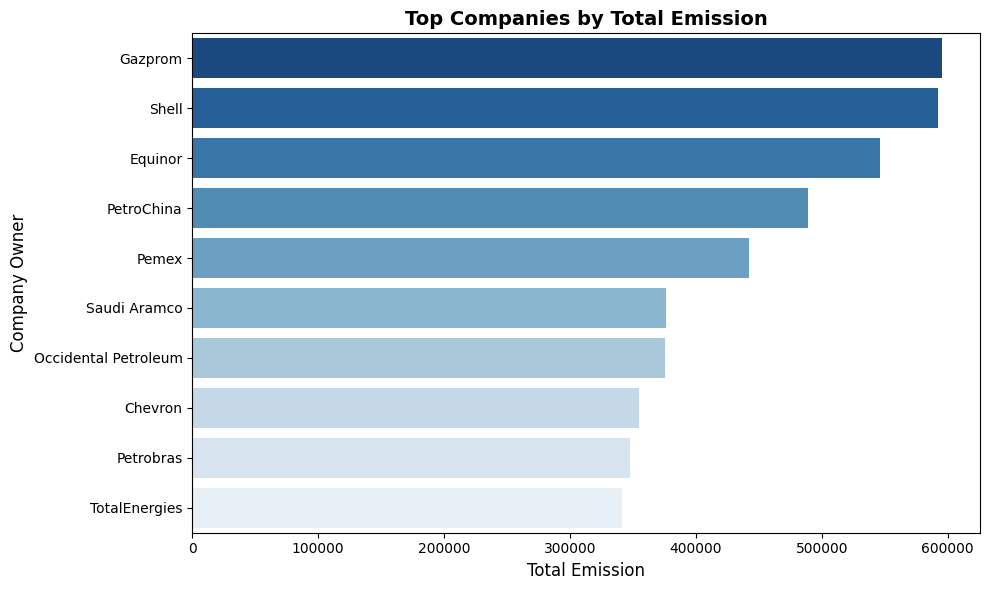

In [53]:
plt.figure(figsize=(10, 6))

# 2. رسم الـ Barplot
sns.barplot(
    data=vis1,
    x='Total_Emission',
    y='immediate_source_owner',
    palette='Blues_r',  # درجات الأزرق (الأغمق للأعلى)
)

# 3. إضافات لتجميل الرسمة
plt.title('Top Companies by Total Emission', fontsize=14, fontweight='bold')
plt.xlabel('Total Emission', fontsize=12)
plt.ylabel('Company Owner', fontsize=12)

# 4. إظهار الرسمة
plt.tight_layout()
plt.show()

In [54]:
query2 = """ 
SELECT
known_super_emitter_flag,
COUNT(*) AS Facilities
FROM Sheet1$
GROUP BY known_super_emitter_flag;

"""

vis2 = pd.read_sql(query2, conn)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_16576\513142958.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  vis2 = pd.read_sql(query2, conn)


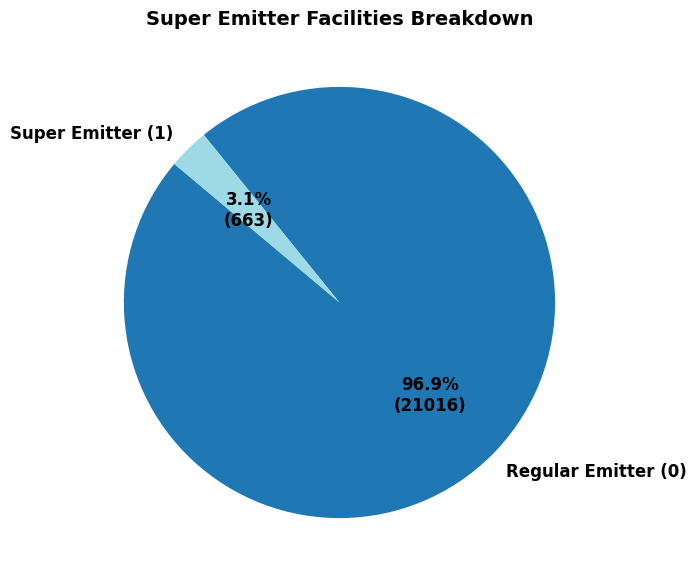

In [60]:
labels = ['Regular Emitter (0)', 'Super Emitter (1)']
sizes = vis2['Facilities']

# 2. تحديد الألوان (أزرق للعادة وبرتقالي/أحمر للـ Super Emitter)
colors = ['#1f77b4', '#9edae5']

# 3. رسم الـ Pie Chart الطبيعية
plt.figure(figsize=(7, 7))
plt.pie(
    sizes,
    labels=labels,
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(sizes)/100)})',  
    startangle=140,  # زاوية بدء الرسم
    colors=colors,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
)

# 4. إضافة عنوان للرسمة
plt.title(
    'Super Emitter Facilities Breakdown', fontsize=14, fontweight='bold'
)

# 5. عرض الرسمة
plt.show()

# Machine Learning Model

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

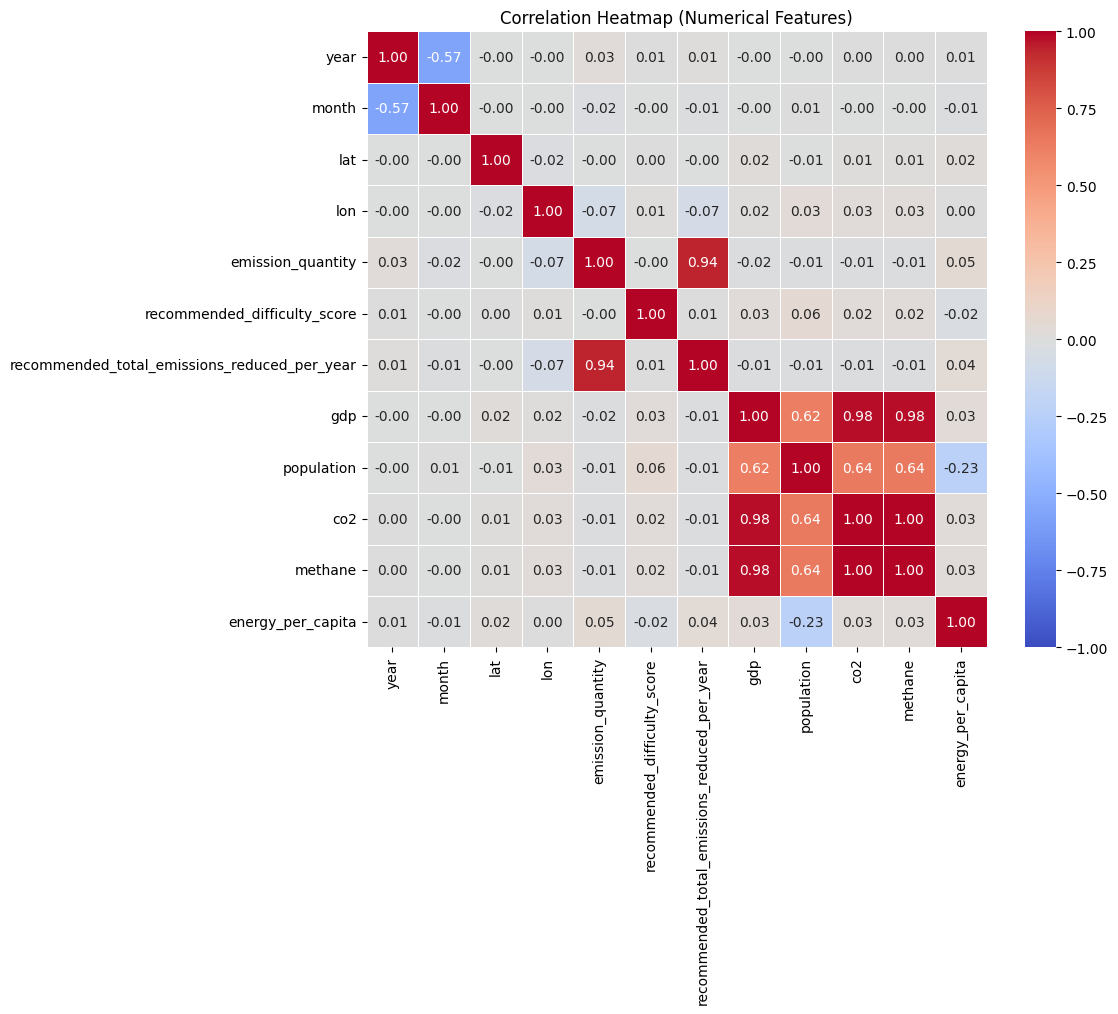

In [ ]:
numeric_data = data.select_dtypes(include=["number"])
corr_matrix = numeric_data.corr()
plt.figure(figsize=(10, 8))  
sns.heatmap(
    corr_matrix,
    annot=True,  
    cmap="coolwarm",  
    fmt=".2f",  
    linewidths=0.5, 
    vmin=-1,
    vmax=1,  )

plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


In [ ]:
X = data[["population","gdp"]]
y = data["methane"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Model Results ===")
print(f"R² Score: {r2:.4f}") 
print(f"MAE: {mae:.4f}")  
print(f"RMSE: {rmse:.4f}") 


=== Model Results ===
R² Score: 0.9457
MAE: 841254.4756
RMSE: 4222139.3304


**Making Sure that there is no Overfitting**

In [ ]:
print("Train R²:", model.score(X_train, y_train))
print("Test R²:", model.score(X_test, y_test))

Train R²: 0.9603651304414702
Test R²: 0.945736057942175


In [48]:
import joblib

In [49]:
joblib.dump(model, "methane_model.pkl")
print("تم حفظ الموديل بنجاح: methane_model.pkl")

تم حفظ الموديل بنجاح: methane_model.pkl
